# Exp 5: Sentiment analysis

In [1]:
import json
import os
import re
import sys
import typing as ty
from collections import Counter
from compression import zstd

import jieba
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

SEED = 0x0d000721

BASE_DIR = "dataset"
SENTIMENT_DICT_PATH = f"{BASE_DIR}/BosonNLP_sentiment_score.txt.zst"
DEGREE_ADV_PATH = f"{BASE_DIR}/程度副词（中文）.txt.zst"
NEGATION_PATH = f"{BASE_DIR}/否定词.txt.zst"
STOP_WORDS_PATH = f"{BASE_DIR}/stoplist.txt.zst"
CSV_PATH = f"{BASE_DIR}/流浪地球.csv.zst"
POS_PATH = f"{BASE_DIR}/pos.txt.zst"
NEG_PATH = f"{BASE_DIR}/neg.txt.zst"

OUT_DIR = "out"
os.makedirs(OUT_DIR, exist_ok=True)

In [2]:
TEST_SENTENCES: tuple[str, ...] = (
    "电影比预期要更恢宏磅礴",
    "煽情显得太尴尬",
    # My own test sentences
    "我不懂，但我大受震撼。",
    "这么好的题材拍成这样也是没谁了，我真的会谢",
)

## 1. Dictionary-based sentiment analysis

```mermaid
flowchart LR
    A("Sentence") --> B["Segmentation"]
    B --> C["Filter stop words"]
    C --> D["Match sentiment dictionary"]
    C --> E["Match degree dictionary"]
    C --> F["Match negation dictionary"]
    D --> G["Compute sentiment score"]
    E --> G
    F --> G
    G --> H("Score")
```

### 1.1. Scoring scheme

In [3]:
def sentiment_score(
    x: ty.Iterable[str],
    sentiment_dict: ty.Mapping[str, float],
    degree_dict: ty.Mapping[str, float],
    negations: ty.Set[str],
    stop_words: ty.Set[str],
) -> float:
    score = 0.0
    w = 1.0
    for word in x:
        if word in stop_words:
            continue
        elif word in degree_dict:
            w *= degree_dict[word]
        elif word in negations:
            w = -w
        elif word in sentiment_dict:
            score += w * sentiment_dict[word]
            w = 1.0

    return score

### 1.2. Load dictionaries

In [4]:
# 超有范 6.04397724361
RE_SENTIMENT_LINE = re.compile(r"^(.+?)\s+(-?\d+(?:\.\d+)?)$")
sentiment_dict: dict[str, float] = {}
with zstd.open(SENTIMENT_DICT_PATH, "rt", encoding="utf-8") as f:
    for line in f:
        match RE_SENTIMENT_LINE.match(line.strip()):
            case None:
                pass
            case m:
                sentiment_dict[m.group(1)] = float(m.group(2))
print(f"Loaded {len(sentiment_dict)} sentiment words")

# 百分之百 2
RE_DEGREE_LINE = re.compile(r"^(.+?)\s+(-?\d+(?:\.\d+)?)$")
degree_dict: dict[str, float] = {}
with zstd.open(DEGREE_ADV_PATH, "rt", encoding="utf-8") as f:
    for line in f:
        match RE_DEGREE_LINE.match(line.strip()):
            case None:
                pass
            case m:
                degree_dict[m.group(1)] = float(m.group(2))
print(f"Loaded {len(degree_dict)} degree adverbs")

# 不大
negations: set[str] = set()
with zstd.open(NEGATION_PATH, "rt", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            negations.add(line)
print(f"Loaded {len(negations)} negation words")

# 啊
stop_words: set[str] = set()
with zstd.open(STOP_WORDS_PATH, "rt", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            stop_words.add(line)
print(f"Loaded {len(stop_words)} stop words")

Loaded 114764 sentiment words
Loaded 214 degree adverbs
Loaded 71 negation words
Loaded 1900 stop words


### 1.3. Evaluation

In [5]:
for s in TEST_SENTENCES:
    words: list[str] = jieba.lcut(s)
    score = sentiment_score(words, sentiment_dict, degree_dict, negations, stop_words)
    print(
        f"'{s}' -> {score:.4f}  ({'positive' if score > 1 else 'negative' if score < -1 else 'neutral'})"
    )
    for w in words:
        if w in stop_words:
            print(f"\t'{w}'\t-\t-")
        elif w in degree_dict:
            print(f"\t'{w}'\tD\t{degree_dict[w]}")
        elif w in negations:
            print(f"\t'{w}'\tN\t-1.0")
        elif w in sentiment_dict:
            print(f"\t'{w}'\tS\t{sentiment_dict[w]:.4f}")
        else:
            print(f"\t'{w}'\t?\t-")
    print()

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\MANTLE~1\AppData\Local\Temp\jieba.cache
Loading model cost 0.471 seconds.
Prefix dict has been built successfully.


'电影比预期要更恢宏磅礴' -> 3.8912  (positive)
	'电影'	S	0.5527
	'比'	-	-
	'预期'	S	0.8613
	'要'	-	-
	'更'	-	-
	'恢宏'	S	2.1157
	'磅礴'	S	0.3615

'煽情显得太尴尬' -> -2.5782  (negative)
	'煽情'	?	-
	'显得'	S	0.6529
	'太'	D	1.5
	'尴尬'	S	-2.1540

'我不懂，但我大受震撼。' -> 2.6909  (positive)
	'我'	-	-
	'不'	-	-
	'懂'	S	0.7089
	'，'	-	-
	'但'	-	-
	'我'	-	-
	'大受'	?	-
	'震撼'	S	1.9821
	'。'	-	-

'这么好的题材拍成这样也是没谁了，我真的会谢' -> 0.8086  (neutral)
	'这么'	-	-
	'好'	-	-
	'的'	-	-
	'题材'	S	0.8387
	'拍'	S	0.8588
	'成'	S	0.3705
	'这样'	-	-
	'也'	-	-
	'是'	-	-
	'没'	-	-
	'谁'	-	-
	'了'	-	-
	'，'	-	-
	'我'	-	-
	'真的'	S	-1.2593
	'会谢'	?	-



## 2. Naive-Bayesian sentiment analysis

Wikipedia[^0]

[^0]: https://en.wikipedia.org/wiki/Naive_Bayes_classifier

### 2.1. Data preparation

In [6]:
with zstd.open(NEG_PATH, "rt", encoding="utf-8") as f:
    neg_reviews = [l for l in map(str.strip, f.readlines()) if l]
with zstd.open(POS_PATH, "rt", encoding="utf-8") as f:
    pos_reviews = [l for l in map(str.strip, f.readlines()) if l]

df_pos_reviews = pd.DataFrame({"text": pos_reviews, "label": 1})
df_neg_reviews = pd.DataFrame({"text": neg_reviews, "label": 0})
df_reviews = pd.concat([df_pos_reviews, df_neg_reviews], ignore_index=True)
print(f"Total: {len(df_reviews)} reviews ({len(df_pos_reviews)} pos, {len(df_neg_reviews)} neg)")

Total: 608 reviews (276 pos, 332 neg)


In [7]:
def tokenize(text: str) -> str:
    filtered = (w for w in jieba.cut(text) if w not in stop_words and w.strip())
    return " ".join(filtered)


df_reviews["tokens"] = df_reviews["text"].apply(tokenize)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    df_reviews["tokens"],
    df_reviews["label"],
    test_size=0.2,
    random_state=SEED,
    stratify=df_reviews["label"],
)
print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

Training set: 486 samples
Test set: 122 samples


### 2.2. Feature extraction

In [9]:
vectorizer = CountVectorizer(
    input="content",
    encoding="utf-8",
    stop_words=None,
    token_pattern=r"(?u)\b\w\w+\b",
    analyzer="word",
    ngram_range=(1, 2),
    max_features=4096,
)
X_train_v = vectorizer.fit_transform(X_train)
X_test_v = vectorizer.transform(X_test)

### 2.3. Training

In [10]:
model = MultinomialNB()
model.fit(X_train_v, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


### 2.4. Evaluation

              precision    recall  f1-score   support

    negative       0.75      0.81      0.78        67
    positive       0.74      0.67      0.70        55

    accuracy                           0.75       122
   macro avg       0.74      0.74      0.74       122
weighted avg       0.75      0.75      0.74       122



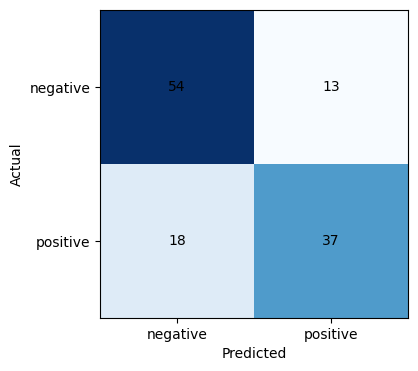

In [11]:
y_pred = model.predict(X_test_v)
print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], ["negative", "positive"])
ax.set_yticks([0, 1], ["negative", "positive"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.show()

In [12]:
def predict(text: str) -> str:
    tokens = tokenize(text)
    vec = vectorizer.transform([tokens])
    neg, pos = model.predict_proba(vec)[0]
    pred = model.predict(vec)[0]
    label = "positive" if pred == 1 else "negative"
    return f"{label}\t(pos={pos:.3f}, neg={neg:.3f})"


for s in TEST_SENTENCES:
    print(f"'{s}'")
    print(f"\tNB: {predict(s)}")

'电影比预期要更恢宏磅礴'
	NB: positive	(pos=0.936, neg=0.064)
'煽情显得太尴尬'
	NB: negative	(pos=0.025, neg=0.975)
'我不懂，但我大受震撼。'
	NB: positive	(pos=0.508, neg=0.492)
'这么好的题材拍成这样也是没谁了，我真的会谢'
	NB: negative	(pos=0.483, neg=0.517)


### 2.5. Features analysis

In [13]:
feature_names = vectorizer.get_feature_names_out()
pos_logprob = model.feature_log_prob_[1]  # positive class
neg_logprob = model.feature_log_prob_[0]  # negative class

ratio = pos_logprob - neg_logprob
top_pos_idx = np.argsort(ratio)[-15:][::-1]
top_neg_idx = np.argsort(ratio)[:15]

print("Top 15 positive features:")
for i in top_pos_idx:
    print(f"\t{feature_names[i]}\t{ratio[i]:+.4f}")
print()

print("Top 15 negative features:")
for i in top_neg_idx:
    print(f"\t{feature_names[i]}\t{ratio[i]:+.4f}")

Top 15 positive features:
	我国	+2.2582
	拯救 世界	+2.2582
	亲情	+2.1404
	地球 小说	+1.8527
	放在	+1.8527
	改动	+1.8527
	电影院	+1.8527
	心情	+1.8527
	科幻 大片	+1.7350
	太尬	+1.6704
	启航	+1.6704
	惊艳	+1.6704
	这是 一部	+1.6704
	末世 场景	+1.6704
	科幻世界	+1.6704

Top 15 negative features:
	联合政府	-2.5040
	视角	-2.5040
	不行	-2.4239
	莫名其妙	-2.2416
	儿戏	-2.1362
	科幻 科幻	-2.0185
	值得 鼓励	-2.0185
	几个	-2.0185
	恶心	-2.0185
	原因	-1.8849
	华为	-1.8849
	居住	-1.8849
	全世界	-1.8849
	关键时刻	-1.7308
	动作	-1.7308
